# 🔬 Exploración de la Base Agrícola Valle del Cauca 2019-2025 (v2)

**Objetivo:** caracterizar el dataset fuente para diseñar el modelo predictivo v3 con criterio.

**v2 corrige:** precedencia de operadores en detección de columnas, normalización de tildes,
patrones permisivos ('ha'), indexación posicional del choque, y detecciones sin guard.
Toda detección de columnas pasa por `detectar_columna()` (celda 0).

In [1]:
# ===== Celda 0: imports, configuración y helpers =====
from pathlib import Path
import unicodedata
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

def normalizar(s):
    """Minúsculas y sin tildes: 'Producción (t)' -> 'produccion (t)'."""
    s = str(s)
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn').lower()

def detectar_columna(df, *patrones, obligatorio=True):
    """Primero busca coincidencia EXACTA (nombre normalizado == patrón);
    si no hay, cae a substring. Los patrones se prueban en orden de prioridad."""
    cols_norm = {c: normalizar(c) for c in df.columns}

    # Paso 1: coincidencia exacta
    for p in patrones:
        exactas = [c for c, cn in cols_norm.items() if cn == p]
        if exactas:
            return exactas[0]

    # Paso 2: substring (fallback)
    for p in patrones:
        candidatas = [c for c, cn in cols_norm.items() if p in cn]
        if candidatas:
            return candidatas[0]

    if obligatorio:
        raise ValueError(f"No se encontro columna para patrones {patrones}. "
                         f"Columnas disponibles: {list(df.columns)}")
    return None

RUTA_XLSX = Path(r"C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx")
print(f"Archivo: {RUTA_XLSX}")
print(f"Existe: {RUTA_XLSX.exists()}")
if RUTA_XLSX.exists():
    print(f"Tamaño: {RUTA_XLSX.stat().st_size / 1024 / 1024:.1f} MB")

Archivo: C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx
Existe: True
Tamaño: 25.1 MB


## Paso 1 — ¿Qué contiene el XLSX?

**Salida esperada:** nombres de hojas y previsualización de cada una.

In [2]:
# ===== Celda 1: inspección de hojas =====
xls = pd.ExcelFile(RUTA_XLSX)
print(f"Número de hojas: {len(xls.sheet_names)}")
for i, nombre in enumerate(xls.sheet_names, 1):
    print(f"  {i}. {nombre}")

print("\n" + "="*80)
for nombre in xls.sheet_names:
    print(f"\n>>> {nombre}")
    prev = pd.read_excel(xls, sheet_name=nombre, nrows=3)
    print(f"    Columnas: {list(prev.columns)}")
    print(prev.head(3).to_string(index=False))

Número de hojas: 2
  1. BasePagina
  2. BaseSIPRA


>>> BasePagina
    Columnas: ['Unnamed: 0']
                                                                                                                                                             Unnamed: 0
                                                                                                                                EVALUACIONES AGROPECUARIAS MUNICIPALES 
                                                                                                                                              BASE AGRÍCOLA 2019 - 2025
Fuente: EVA -UPRA, con base en información de: Municipios, SICA de la Federación Nacional de Cafeteros, ENAM -DANE y Fedearroz;  y agremiaciones de productores locales

>>> BaseSIPRA
    Columnas: ['codigoDepartamento', 'departamento', 'codigoMunicipio', 'municipio', 'especie', 'nombre_tipo_ciclo', 'grupo_especie', 'subGrupo_Especie', 'anho', 'Periodo', 'AreaSembrada', 'AreaCosechada', 'produccio'

## Paso 2 — Carga de la hoja principal

**Criterio:** ajusta `HOJA_PRINCIPAL` según el Paso 1.

In [3]:
# ===== Celda 2: carga principal + filtro departamental =====
FILA_ENCABEZADO = 8
DEPARTAMENTO_OBJETIVO = 'Valle del Cauca'

xls = pd.ExcelFile(RUTA_XLSX)          # <-- asegura que xls exista
HOJA_PRINCIPAL = xls.sheet_names[0]    # <-- asegura que HOJA_PRINCIPAL exista

df = pd.read_excel(RUTA_XLSX, sheet_name=HOJA_PRINCIPAL, header=FILA_ENCABEZADO)
df = df.dropna(axis=1, how='all')
df.columns = [str(c).strip() for c in df.columns]

print(f"Shape original: {df.shape}")
print(f"\nDepartamentos presentes en el archivo:")
print(df['Departamento'].value_counts())

mask_valle = df['Departamento'].map(normalizar).str.strip() == normalizar(DEPARTAMENTO_OBJETIVO)
df = df[mask_valle].copy()

print(f"\nShape tras filtrar {DEPARTAMENTO_OBJETIVO}: {df.shape}")
print(f"Municipios encontrados ({df['Municipio'].nunique()}):")
print(sorted(df['Municipio'].unique()))

Shape original: (166733, 18)

Departamentos presentes en el archivo:
Departamento
Boyacá                                                      17679
Cundinamarca                                                15585
Antioquia                                                   15216
Santander                                                   13071
Huila                                                       11769
Nariño                                                      11568
Valle del Cauca                                             10589
Cauca                                                        7518
Norte de Santander                                           7125
Tolima                                                       6688
Bolívar                                                      4834
Magdalena                                                    4295
Cesar                                                        4268
Meta                                                        

In [4]:
# ===== Diagnóstico: ver las primeras 10 filas SIN asumir encabezado =====
raw = pd.read_excel(RUTA_XLSX, sheet_name=HOJA_PRINCIPAL, header=None, nrows=20)
display(raw)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EVALUACIONES AGROPECUARIAS MUNICIPALES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BASE AGRÍCOLA 2019 - 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Fuente: EVA -UPRA, con base en información de:...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"* Los datos de área cosechada, producción y re...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,* Las cifras de los dos últimos años son susce...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"* El municipio Nuevo Belén de Bajirá, código 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,* Se ajustaron las cifras de producción y rend...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Desagregación cultivo,Cultivo,Ciclo del cultivo,Grupo cultivo,Subgrupo,Año,Periodo,Área sembrada (ha),Área cosechada (ha),Producción (t),Rendimiento (t/ha),Nombre científico del cultivo,Código del cultivo,Estado físico del cultivo
9,05,Antioquia,05001,Medellín,Apio,Apio,Transitorio,Hortalizas,Hortalizas de tallo,2021,2021A,8,8,128,16,Apium graveolens,1050600,En fresco


## Paso 3 — Inventario de columnas

In [5]:
# ===== Celda 3: inventario =====
for col in df.columns:
    nulos = df[col].isna().sum()
    print(f"\n📋 {col!r}  |  tipo: {df[col].dtype}  |  únicos: {df[col].nunique():,}  |  nulos: {nulos:,}")
    muestra = df[col].dropna().iloc[:3].tolist()
    print(f"   muestra: {muestra}")
    if df[col].dtype in ['int64', 'float64']:
        print(f"   rango: {df[col].min():,.2f} → {df[col].max():,.2f} | media: {df[col].mean():,.2f}")


📋 'Código Dane departamento'  |  tipo: int64  |  únicos: 1  |  nulos: 0
   muestra: [76, 76, 76]
   rango: 76.00 → 76.00 | media: 76.00

📋 'Departamento'  |  tipo: str  |  únicos: 1  |  nulos: 0
   muestra: ['Valle del Cauca', 'Valle del Cauca', 'Valle del Cauca']

📋 'Código Dane municipio'  |  tipo: int64  |  únicos: 42  |  nulos: 0
   muestra: [76001, 76001, 76001]
   rango: 76,001.00 → 76,895.00 | media: 76,436.27

📋 'Municipio'  |  tipo: str  |  únicos: 42  |  nulos: 0
   muestra: ['Santiago de Cali', 'Santiago de Cali', 'Santiago de Cali']

📋 'Desagregación cultivo'  |  tipo: str  |  únicos: 97  |  nulos: 0
   muestra: ['Acelga', 'Acelga', 'Acelga']

📋 'Cultivo'  |  tipo: str  |  únicos: 78  |  nulos: 0
   muestra: ['Acelga', 'Acelga', 'Acelga']

📋 'Ciclo del cultivo'  |  tipo: str  |  únicos: 2  |  nulos: 0
   muestra: ['Transitorio', 'Transitorio', 'Transitorio']

📋 'Grupo cultivo'  |  tipo: str  |  únicos: 8  |  nulos: 0
   muestra: ['Hortalizas', 'Hortalizas', 'Hortalizas']



## Paso 4 — Detección de claves y cobertura

Toda detección usa `detectar_columna()` con patrones normalizados (sin tildes).

In [6]:
# ===== Celda 4: claves + descomposición temporal =====
col_ano  = detectar_columna(df, 'ano', 'anio', 'periodo', 'year')
col_muni = detectar_columna(df, 'municipio', 'munic')
col_cult = detectar_columna(df, 'cultivo', 'especie')
col_per  = detectar_columna(df, 'periodo', obligatorio=False)

df[col_ano] = pd.to_numeric(df[col_ano], errors='coerce')
n_sin_ano = df[col_ano].isna().sum()
if n_sin_ano:
    print(f"⚠️ {n_sin_ano} filas sin año convertible; se excluyen")
    df = df.dropna(subset=[col_ano])
df[col_ano] = df[col_ano].astype(int)

if col_per:
    df['semestre'] = df[col_per].astype(str).str.extract(r'([AB])$')
    n_sin_sem = df['semestre'].isna().sum()
    if n_sin_sem:
        print(f"⚠️ {n_sin_sem} filas sin semestre identificable en '{col_per}'")
    print(f"\nValores de {col_per}: {sorted(df[col_per].dropna().unique())}")
    print(f"Semestres detectados: {df['semestre'].value_counts().to_dict()}")
else:
    print("⚠️ No se encontró columna de Periodo; el análisis semestral no será posible")

print(f"\nClaves: año={col_ano!r} | municipio={col_muni!r} | cultivo={col_cult!r} | periodo={col_per!r}")
print(f"📅 Años: {sorted(df[col_ano].unique())}")
print(f"🏘️ Municipios: {df[col_muni].nunique()}")
print(f"🌾 Cultivos: {df[col_cult].nunique()}")

⚠️ 4681 filas sin semestre identificable en 'Periodo'

Valores de Periodo: ['2019', '2019A', '2019B', '2020', '2020A', '2020B', '2021', '2021A', '2021B', '2022', '2022A', '2022B', '2023', '2023A', '2023B', '2024', '2024A', '2024B', '2025', '2025A', '2025B']
Semestres detectados: {'A': 3050, 'B': 2858}

Claves: año='Año' | municipio='Municipio' | cultivo='Cultivo' | periodo='Periodo'
📅 Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
🏘️ Municipios: 42
🌾 Cultivos: 78


## Paso 5 — Longitudes de serie (estratos para v3)

Columna de producción: 'Producción (t)'
Series totales: 1,182

Distribución de longitudes:
   1 años:    53 series (  4.5%)
   2 años:    83 series (  7.0%)
   3 años:    23 series (  1.9%)
   4 años:    16 series (  1.4%)
   5 años:   120 series ( 10.2%)
   6 años:    93 series (  7.9%)
   7 años:   794 series ( 67.2%)

Top 15 por producción acumulada:


Municipio            Cultivo
Palmira              Caña      32,660,389.00
Candelaria           Caña      20,830,414.00
El Cerrito           Caña      14,250,600.00
Guacarí              Caña      11,920,388.00
Zarzal               Caña       9,867,793.00
Florida              Caña       9,624,851.00
Bugalagrande         Caña       9,447,376.00
Pradera              Caña       8,439,294.00
Jamundí              Caña       6,761,610.00
Obando               Caña       6,707,526.00
Guadalajara de Buga  Caña       6,646,300.00
Tuluá                Caña       5,484,737.00
Cartago              Caña       4,231,129.00
San Pedro            Caña       3,932,314.00
Andalucía            Caña       3,322,231.00
Name: Producción (t), dtype: float64

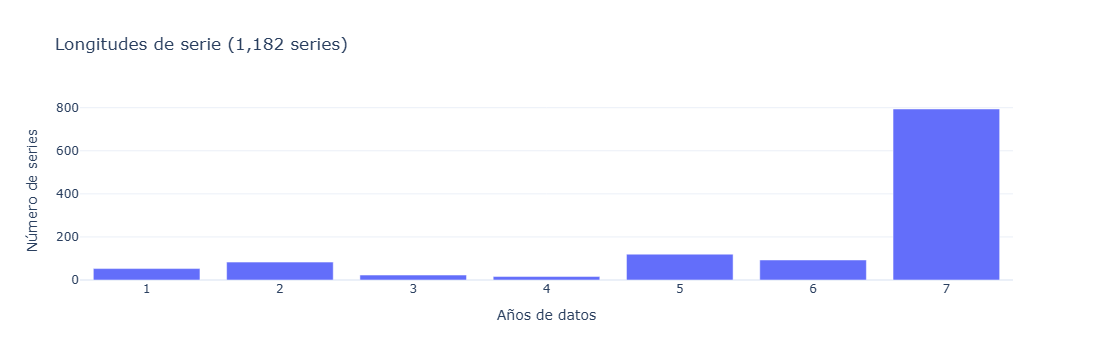

In [7]:
# ===== Celda 5: longitudes =====
col_prod = detectar_columna(df, 'produccion ton', 'produccion_t', 'produccion (t',
                            'produccion', 'toneladas')
print(f"Columna de producción: {col_prod!r}")

g = df.groupby([col_muni, col_cult])[col_ano].nunique().rename('n_anos')
print(f"Series totales: {len(g):,}")

dist = g.value_counts().sort_index()
print("\nDistribución de longitudes:")
for n, count in dist.items():
    print(f"   {n} años: {count:5,} series ({count/len(g)*100:5.1f}%)")

print("\nTop 15 por producción acumulada:")
display(df.groupby([col_muni, col_cult])[col_prod].sum()
          .sort_values(ascending=False).head(15).round(0))

fig = px.bar(x=dist.index.astype(str), y=dist.values,
             title=f"Longitudes de serie ({len(g):,} series)",
             labels={'x': 'Años de datos', 'y': 'Número de series'})
fig.update_layout(template='plotly_white')
fig.show()

## Paso 6 — Choque 2020-2021: agregado y por cultivo top

,anio,produccion_total,var_pct
0,2019,"24,713,772.33",NaN
1,2020,"24,752,592.68",0.16
2,2021,"25,880,893.10",4.56
3,2022,"25,861,658.62",-0.07
4,2023,"26,731,968.61",3.37
5,2024,"28,153,411.10",5.32
6,2025,"28,552,739.99",1.42


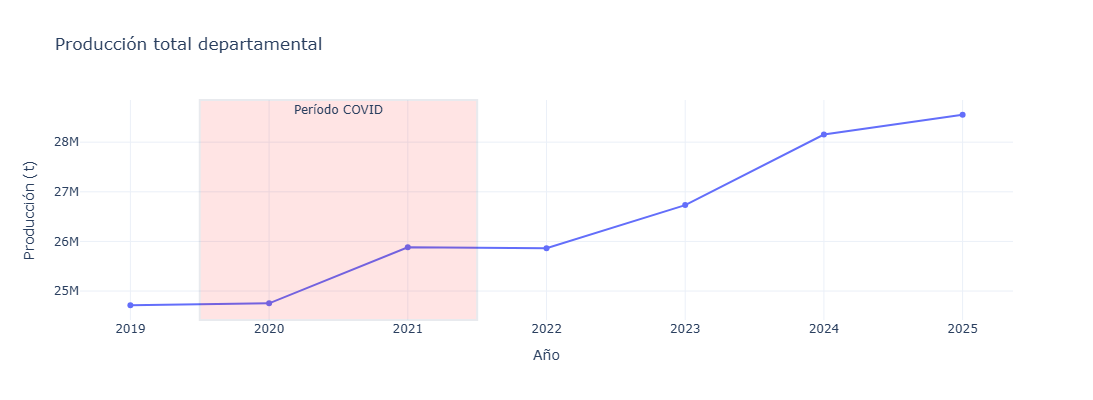

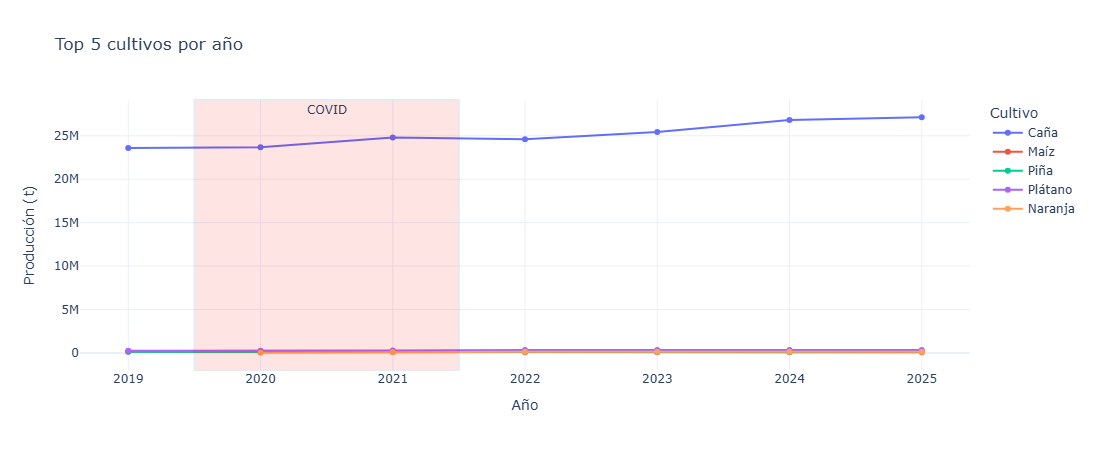

In [8]:
# ===== Celda 6: choque =====
prod_anual = (df.groupby(col_ano)[col_prod].sum()
                .reset_index()
                .rename(columns={col_ano: 'anio', col_prod: 'produccion_total'}))
prod_anual['var_pct'] = prod_anual['produccion_total'].pct_change() * 100
display(prod_anual)

fig = px.line(prod_anual, x='anio', y='produccion_total', markers=True,
              title='Producción total departamental',
              labels={'produccion_total': 'Producción (t)', 'anio': 'Año'})
fig.add_vrect(x0=2019.5, x1=2021.5, fillcolor='red', opacity=0.1,
              annotation_text='Período COVID', annotation_position='top')
fig.update_layout(template='plotly_white', height=400)
fig.show()

top_cultivos = df.groupby(col_cult)[col_prod].sum().nlargest(5).index
df_top = df[df[col_cult].isin(top_cultivos)]
agg_top = df_top.groupby([col_ano, col_cult])[col_prod].sum().reset_index()

fig = px.line(agg_top, x=col_ano, y=col_prod, color=col_cult, markers=True,
              title='Top 5 cultivos por año',
              labels={col_prod: 'Producción (t)'})
fig.add_vrect(x0=2019.5, x1=2021.5, fillcolor='red', opacity=0.1,
              annotation_text='COVID', annotation_position='top')
fig.update_layout(template='plotly_white', height=450)
fig.show()

## Paso 7 — Consistencia agronómica (área y rendimiento)

Patrones específicos: sin `'ha'` suelto (matchearía 'Fecha', 'Cosecha'...).

área sembrada: 'Área sembrada (ha)' | área cosechada: 'Área cosechada (ha)'
rendimiento:   'Rendimiento (t/ha)' | área usada: 'Área cosechada (ha)'

Filas con área > 0: 10,390 de 10,589

Desviación |rend_calc − rend_reportado| (%):


count   10,390.00
mean         0.02
std          0.10
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          3.23
Name: desv_pct, dtype: float64

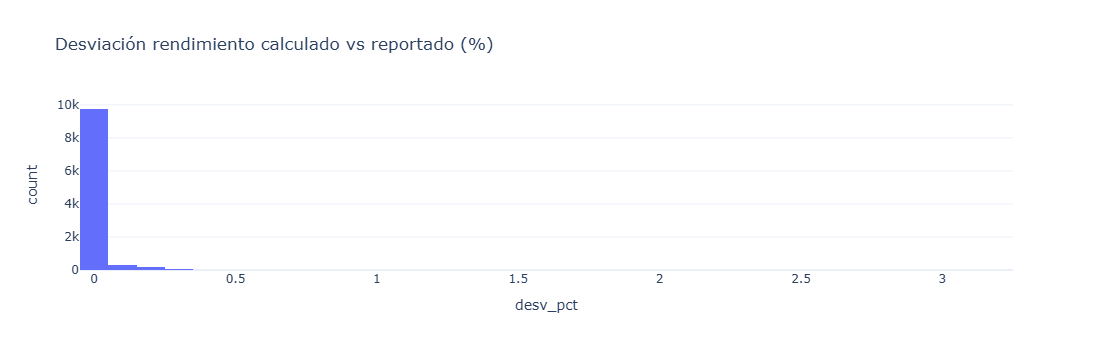

In [9]:
# ===== Celda 7: consistencia =====
col_area_sem = detectar_columna(df, 'area sembrada', obligatorio=False)
col_area_cos = detectar_columna(df, 'area cosechada', obligatorio=False)
col_rend     = detectar_columna(df, 'rendimiento', obligatorio=False)
col_area     = col_area_cos or col_area_sem or detectar_columna(df, 'hectarea', 'area', obligatorio=False)

print(f"área sembrada: {col_area_sem!r} | área cosechada: {col_area_cos!r}")
print(f"rendimiento:   {col_rend!r} | área usada: {col_area!r}")

if col_area and col_rend:
    d = df[df[col_area] > 0].copy()
    d['rend_calc'] = d[col_prod] / d[col_area]
    d['desv_pct'] = (d['rend_calc'] - d[col_rend]).abs() / d[col_rend].replace(0, np.nan) * 100
    print(f"\nFilas con área > 0: {len(d):,} de {len(df):,}")
    print("\nDesviación |rend_calc − rend_reportado| (%):")
    display(d['desv_pct'].describe().round(2))
    fig = px.histogram(d, x='desv_pct', nbins=60,
                       title='Desviación rendimiento calculado vs reportado (%)')
    fig.update_layout(template='plotly_white', height=350)
    fig.show()
else:
    print("\n⚠️ Sin par área+rendimiento en este archivo.")

## Paso 8 — Caso de estudio: Plátano en Sevilla (nombres normalizados)

Registros: 7


,Año,Municipio,Cultivo,Producción (t),Área cosechada (ha),Rendimiento (t/ha)
157846,2019,Sevilla,Plátano,"40,830.00","4,083.00",10.00
157847,2020,Sevilla,Plátano,"30,198.00","4,314.00",7.00
157848,2021,Sevilla,Plátano,"30,100.94","4,294.00",7.01
157849,2022,Sevilla,Plátano,"77,832.00","4,324.00",18.00
157850,2023,Sevilla,Plátano,"77,850.00","4,325.00",18.00
157851,2024,Sevilla,Plátano,"77,796.00","4,322.00",18.00
157852,2025,Sevilla,Plátano,"81,630.00","4,535.00",18.00


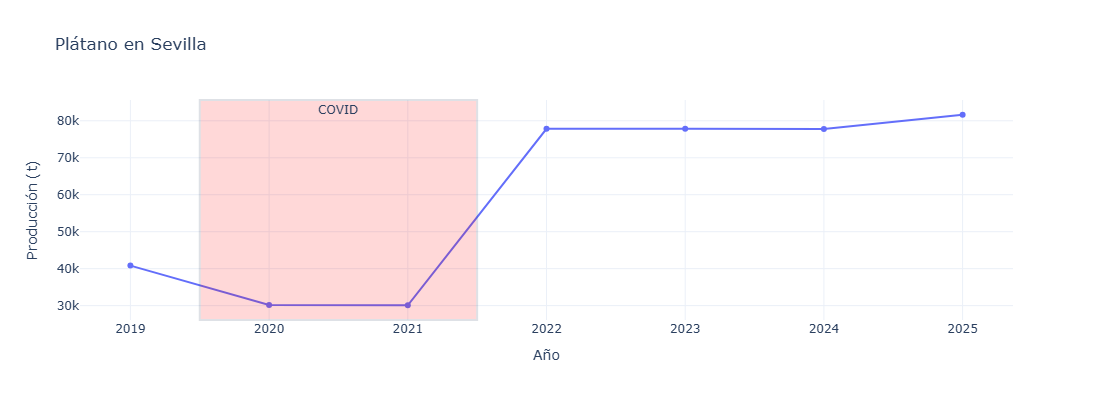

In [10]:
# ===== Celda 8: caso Plátano/Sevilla =====
mask_cult = df[col_cult].map(normalizar).str.contains('platano', na=False)
mask_muni = df[col_muni].map(normalizar).str.contains('sevilla', na=False)
serie = df[mask_cult & mask_muni].sort_values(col_ano)

print(f"Registros: {len(serie)}")
cols_ver = [col_ano, col_muni, col_cult, col_prod] + ([col_area] if col_area else []) + ([col_rend] if col_rend else [])
display(serie[cols_ver])

if len(serie):
    fig = px.line(serie, x=col_ano, y=col_prod, markers=True,
                  title=f"{serie[col_cult].iloc[0]} en {serie[col_muni].iloc[0]}",
                  labels={col_prod: 'Producción (t)'})
    fig.add_vrect(x0=2019.5, x1=2021.5, fillcolor='red', opacity=0.15,
                  annotation_text='COVID', annotation_position='top')
    fig.update_layout(template='plotly_white', height=400)
    fig.show()

## Paso 9 — Resumen ejecutivo y decisiones habilitadas

El choque se filtra **por valor de año**, no por posición de fila.

In [11]:
# ===== Celda 9: resumen =====
choque_vals = (prod_anual[prod_anual['anio'].isin([2020, 2021])]['produccion_total']
               .round(0).tolist())

resumen = pd.DataFrame({
    'Hallazgo': [
        'Filas totales', 'Series únicas (muni×cultivo)', 'Cobertura temporal',
        'Municipios', 'Cultivos', 'Series n=7', 'Series n=4-6',
        'Producción 2020-2021 (choque)', 'Variables agronómicas',
    ],
    'Valor': [
        f"{len(df):,}", f"{len(g):,}",
        f"{df[col_ano].min()}-{df[col_ano].max()} ({df[col_ano].nunique()} años)",
        f"{df[col_muni].nunique()}", f"{df[col_cult].nunique()}",
        f"{int((g == 7).sum()):,} ({(g == 7).mean()*100:.1f}%)",
        f"{int(g.between(4, 6).sum()):,} ({g.between(4, 6).mean()*100:.1f}%)",
        f"{choque_vals}",
        ', '.join([c for c in [col_area_sem, col_area_cos, col_rend] if c]) or 'Ninguna',
    ]
})
display(resumen)

print("\n" + "="*80)
print("LECTURAS PARA v3 (se completan con la salida de esta celda)")
print("="*80)
print("""
1. PANEL POOLED: viable si hay miles de filas-panel; cubre series cortas n=4-6.
2. ANOS_CHOQUE: confirmar con la gráfica del Paso 6 que 2020-2021 es el hueco.
3. FEATURES AGRONÓMICAS: si la desviación del Paso 7 es ~0, rendimiento reportado
   es confiable; en v3 se usa siempre LAGGEADO (rendimiento t-1) para no fugar.
4. MLP serie única: retirado del ensemble de producción (n=7 insuficiente).
5. SIGUIENTE: harness de validación selección-pura vs combinación top-k.
""")

,Hallazgo,Valor
0,Filas totales,"10,589"
1,Series únicas (muni×cultivo),"1,182"
2,Cobertura temporal,2019-2025 (7 años)
3,Municipios,42
4,Cultivos,78
5,Series n=7,794 (67.2%)
6,Series n=4-6,229 (19.4%)
7,Producción 2020-2021 (choque),"[24752593.0, 25880893.0]"
8,Variables agronómicas,"Área sembrada (ha), Área cosechada (ha), Rendi..."



LECTURAS PARA v3 (se completan con la salida de esta celda)

1. PANEL POOLED: viable si hay miles de filas-panel; cubre series cortas n=4-6.
2. ANOS_CHOQUE: confirmar con la gráfica del Paso 6 que 2020-2021 es el hueco.
3. FEATURES AGRONÓMICAS: si la desviación del Paso 7 es ~0, rendimiento reportado
   es confiable; en v3 se usa siempre LAGGEADO (rendimiento t-1) para no fugar.
4. MLP serie única: retirado del ensemble de producción (n=7 insuficiente).
5. SIGUIENTE: harness de validación selección-pura vs combinación top-k.



In [12]:
# ===== Diagnóstico: filas con Periodo sin semestre =====
sin_sem = df[df['semestre'].isna()]
print(f"Filas sin semestre: {len(sin_sem):,}")

# ¿Qué cultivos son? ¿Coinciden con los mismos municipio×cultivo×año que también tienen A y B?
print("\nCultivos más frecuentes en filas sin semestre:")
print(sin_sem[col_cult].value_counts().head(15))

# Prueba de duplicidad: tomar un caso y ver si existe la misma combinación con A/B Y con año plano
ejemplo = sin_sem.groupby([col_muni, col_cult, col_ano]).size().reset_index(name='n')
ejemplo_check = ejemplo.iloc[0]
print(f"\nEjemplo a verificar: {ejemplo_check[col_muni]} / {ejemplo_check[col_cult]} / {ejemplo_check[col_ano]}")
verificacion = df[(df[col_muni]==ejemplo_check[col_muni]) & 
                  (df[col_cult]==ejemplo_check[col_cult]) & 
                  (df[col_ano]==ejemplo_check[col_ano])]
display(verificacion[[col_ano, 'Periodo', col_prod]])

Filas sin semestre: 4,681

Cultivos más frecuentes en filas sin semestre:
Cultivo
Caña         435
Aguacate     404
Plátano      283
Café         273
Banano       263
Maracuyá     238
Cacao        234
Guayaba      208
Limón        200
Lulo         194
Naranja      166
Mandarina    164
Papaya       162
Mora         161
Guanábana    160
Name: count, dtype: int64

Ejemplo a verificar: Alcalá / Aguacate / 2019


,Año,Periodo,Producción (t)
149996,2019,2019,"1,185.60"


In [13]:
# ===== Diagnóstico: ¿las filas "solo año" duplican A+B? =====
sin_sem = df[df['semestre'].isna()]
print(f"Filas sin semestre: {len(sin_sem):,}")
print("\nCultivos más frecuentes en filas sin semestre:")
print(sin_sem[col_cult].value_counts().head(10))

# Tomar un cultivo que aparezca en filas sin semestre y ver si coexiste con A/B
cultivo_ejemplo = sin_sem[col_cult].value_counts().index[0]
muni_ejemplo = sin_sem[sin_sem[col_cult] == cultivo_ejemplo][col_muni].iloc[0]

verificacion = df[(df[col_muni] == muni_ejemplo) & (df[col_cult] == cultivo_ejemplo)]
print(f"\nCaso: {muni_ejemplo} / {cultivo_ejemplo}")
display(verificacion[[col_ano, 'Periodo', col_prod]].sort_values(col_ano))

Filas sin semestre: 4,681

Cultivos más frecuentes en filas sin semestre:
Cultivo
Caña        435
Aguacate    404
Plátano     283
Café        273
Banano      263
Maracuyá    238
Cacao       234
Guayaba     208
Limón       200
Lulo        194
Name: count, dtype: int64

Caso: Santiago de Cali / Caña


,Año,Periodo,Producción (t)
149736,2019,2019,"465,000.00"
149737,2020,2020,"465,000.00"
149738,2021,2021,"464,953.50"
149739,2022,2022,"465,000.00"
149740,2023,2023,"465,000.00"
149741,2024,2024,"465,000.00"
149742,2025,2025,"465,000.00"


In [14]:
# ===== Verificación: ¿alguna combinación tiene AMBOS formatos en el mismo año? =====
df['tipo_periodo'] = np.where(df['semestre'].isna(), 'anual', 'semestral')

mezcla = (df.groupby([col_muni, col_cult, col_ano])['tipo_periodo']
            .nunique()
            .reset_index(name='n_tipos'))

casos_mezclados = mezcla[mezcla['n_tipos'] > 1]
print(f"Combinaciones muni×cultivo×año con AMBOS formatos: {len(casos_mezclados)}")
if len(casos_mezclados) > 0:
    display(casos_mezclados.head(10))

Combinaciones muni×cultivo×año con AMBOS formatos: 2


,Municipio,Cultivo,Año,n_tipos
2751,Guacarí,Plantas aromáticas,2020,2
3347,La Cumbre,Plantas aromáticas,2025,2


In [15]:
# ===== Celda 5B (ajustada): solo combinaciones con reporte semestral =====
df_semestral = df[df['tipo_periodo'] == 'semestral'].copy()

print(f"Filas semestrales: {len(df_semestral):,} de {len(df):,} totales")
print(f"Combinaciones muni×cultivo con dato semestral: "
      f"{df_semestral.groupby([col_muni, col_cult]).ngroups:,} de {df.groupby([col_muni, col_cult]).ngroups:,} totales")
print(f"\n⚠️ Cultivos EXCLUIDOS del análisis semestral (solo reportan anual):")
cultivos_solo_anual = set(df[col_cult].unique()) - set(df_semestral[col_cult].unique())
print(sorted(cultivos_solo_anual))

g_sem = df_semestral.groupby([col_muni, col_cult])['Periodo'].nunique().rename('n_periodos')
print(f"\nSeries semestrales totales: {len(g_sem):,}")
dist_sem = g_sem.value_counts().sort_index()
for n, count in dist_sem.items():
    print(f"   {n} periodos: {count:5,} series ({count/len(g_sem)*100:5.1f}%)")

Filas semestrales: 5,908 de 10,589 totales
Combinaciones muni×cultivo con dato semestral: 471 de 1,182 totales

⚠️ Cultivos EXCLUIDOS del análisis semestral (solo reportan anual):
['Aguacate', 'Arazá', 'Banano', 'Borojó', 'Brevo', 'Cacao', 'Café', 'Caña', 'Chontaduro', 'Coco', 'Curuba', 'Cúrcuma o azafrán', 'Durazno o albaricoque', 'Fresa', 'Granadilla', 'Guanábana', 'Guayaba', 'Gulupa o cholupa', 'Lima', 'Limón', 'Lulo', 'Macadamia', 'Mandarina', 'Mango', 'Maracuyá', 'Mora', 'Naranja', 'Otros cítricos', 'Papaya', 'Pitahaya', 'Piña', 'Plátano', 'Sacha inchi', 'Stevia', 'Sábila', 'Tomate de árbol', 'Té', 'Uchuva', 'Uva', 'Zapote']

Series semestrales totales: 471
   1 periodos:    25 series (  5.3%)
   2 periodos:    22 series (  4.7%)
   3 periodos:    13 series (  2.8%)
   4 periodos:    22 series (  4.7%)
   5 periodos:     7 series (  1.5%)
   6 periodos:    13 series (  2.8%)
   7 periodos:    13 series (  2.8%)
   8 periodos:    12 series (  2.5%)
   9 periodos:     8 series (  1.

In [16]:
# ===== Verificación de los 2 casos mezclados =====
casos = [('Guacarí', 'Plantas aromáticas', 2020), ('La Cumbre', 'Plantas aromáticas', 2025)]

for muni, cult, anio in casos:
    print(f"\n{'='*60}\n{muni} / {cult} / {anio}")
    sub = df[(df[col_muni]==muni) & (df[col_cult]==cult) & (df[col_ano]==anio)]
    display(sub[[col_ano, 'Periodo', col_prod]])


Guacarí / Plantas aromáticas / 2020


,Año,Periodo,Producción (t)
154461,2020,2020,0.00
154462,2020,2020A,40.00
154463,2020,2020B,45.00



La Cumbre / Plantas aromáticas / 2025


,Año,Periodo,Producción (t)
154954,2025,2025,29.00
154955,2025,2025A,18.00
154956,2025,2025B,18.00


In [17]:
# ===== Fix: eliminar la fila "anual plana" cuando coexiste con A/B =====
# Para las combinaciones con ambos formatos, la fila plana es redundante (agregado de A+B)
idx_redundantes = df.merge(
    casos_mezclados[[col_muni, col_cult, col_ano]],
    on=[col_muni, col_cult, col_ano]
)
idx_a_eliminar = df[
    df.set_index([col_muni, col_cult, col_ano]).index.isin(
        casos_mezclados.set_index([col_muni, col_cult, col_ano]).index
    ) & df['semestre'].isna()
].index

print(f"Filas a eliminar (agregado redundante en casos mezclados): {len(idx_a_eliminar)}")
df = df.drop(index=idx_a_eliminar)

# Recalcular tipo_periodo tras el drop
df['tipo_periodo'] = np.where(df['semestre'].isna(), 'anual', 'semestral')
print(f"Shape final tras limpieza: {df.shape}")

Filas a eliminar (agregado redundante en casos mezclados): 2
Shape final tras limpieza: (10587, 20)


In [18]:
# ===== Nota de calidad de datos: casos con inconsistencia anual vs semestral =====
print("⚠️ CASOS CON INCONSISTENCIA DE DATOS (resuelto usando semestral A+B como fuente de verdad):")
print("""
1. Guacarí / Plantas aromáticas / 2020:
   - Valor anual reportado: 0.00 t
   - Valor semestral (A+B): 85.00 t  →  diferencia total, se usa semestral.

2. La Cumbre / Plantas aromáticas / 2025:
   - Valor anual reportado: 29.00 t
   - Valor semestral (A+B): 36.00 t  →  diferencia de 7.00 t (24% relativo), se usa semestral.

Impacto: mínimo a nivel departamental (2 de 1,182 series, cultivo de bajo volumen),
pero indica que la fuente EVA-UPRA puede tener registros anuales no reconciliados
con su propia desagregación semestral en casos aislados. Recomendación para v3:
si se automatiza el pipeline de ingesta, agregar un chequeo de consistencia
anual == suma(semestral) como validación de calidad de datos en cada corrida futura.
""")

⚠️ CASOS CON INCONSISTENCIA DE DATOS (resuelto usando semestral A+B como fuente de verdad):

1. Guacarí / Plantas aromáticas / 2020:
   - Valor anual reportado: 0.00 t
   - Valor semestral (A+B): 85.00 t  →  diferencia total, se usa semestral.

2. La Cumbre / Plantas aromáticas / 2025:
   - Valor anual reportado: 29.00 t
   - Valor semestral (A+B): 36.00 t  →  diferencia de 7.00 t (24% relativo), se usa semestral.

Impacto: mínimo a nivel departamental (2 de 1,182 series, cultivo de bajo volumen),
pero indica que la fuente EVA-UPRA puede tener registros anuales no reconciliados
con su propia desagregación semestral en casos aislados. Recomendación para v3:
si se automatiza el pipeline de ingesta, agregar un chequeo de consistencia
anual == suma(semestral) como validación de calidad de datos en cada corrida futura.



In [19]:
# ===== Paso 10: verificar que Ciclo del cultivo explica la partición anual/semestral =====
tabla_ciclo = (df.groupby([col_cult, 'Ciclo del cultivo'])['tipo_periodo']
                 .agg(lambda x: x.mode().iloc[0])
                 .reset_index())

cruce = pd.crosstab(df['Ciclo del cultivo'], df['tipo_periodo'])
print("Cruce Ciclo del cultivo × tipo_periodo (conteo de filas):")
display(cruce)

# ¿Hay cultivos "Transitorio" que solo reportan anual, o "Permanente" que sí reportan semestral?
inconsistentes = (df.groupby(col_cult)
                    .agg(ciclo=('Ciclo del cultivo', lambda x: x.mode().iloc[0]),
                         tipos=('tipo_periodo', lambda x: set(x)))
                    .reset_index())
inconsistentes['n_tipos'] = inconsistentes['tipos'].apply(len)
casos_atipicos = inconsistentes[inconsistentes['n_tipos'] > 1]
print(f"\nCultivos que mezclan tipo_periodo (deberían ser 0 o pocos si Ciclo explica todo): {len(casos_atipicos)}")
display(casos_atipicos)

Cruce Ciclo del cultivo × tipo_periodo (conteo de filas):


tipo_periodo,anual,semestral
Ciclo del cultivo,,
Permanente,4641,2
Transitorio,38,5906



Cultivos que mezclan tipo_periodo (deberían ser 0 o pocos si Ciclo explica todo): 2


,Cultivo,ciclo,tipos,n_tipos
59,Plantas aromáticas,Transitorio,"{anual, semestral}",2
63,Romero,Permanente,"{anual, semestral}",2
